**LA ECUACIÓN DE BLACK-SCHOLES – PROBLEMAS**

###### Autor:

* Mario Martínez Escrivá

In [11]:
# Importación de librerías necesarias para la práctica
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# Problema 1: El método de Crank-Nicholson para la ecuación de Black-Scholes

En este problema vamos a considerar el método de Crank-Nicholson para la ecuación de Black - Scholes. Este método se puede considerar una media entre el método explícito FTCS y el método implícito BTCS. En concreto el método discretiza la ecuación de Black - Scholes de la siguiente manera:

$$\frac{V_{m,n+1} - V_{m,n}}{\Delta t} = \frac{1}{2} \left\{ \frac{1}{2}\sigma^2 S_m^2 \frac{V_{m+1,n} - 2V_{m,n} + V_{m-1,n}}{\Delta S^2} + rS_m \frac{V_{m+1,n} - V_{m-1,n}}{2\Delta S} - rV_{m,n} \right\} + \frac{1}{2} \left\{ \frac{1}{2}\sigma^2 S_m^2 \frac{V_{m+1,n+1} - 2V_{m,n+1} + V_{m-1,n+1}}{\Delta S^2} + rS_m \frac{V_{m+1,n+1} - V_{m-1,n+1}}{2\Delta S} - rV_{m,n+1} \right\}$$

para $n = 1, \dots , N_t - 1$ y para $m = 1, \dots , N_x - 1$.

---

## Apartado a) Forma Matricial

Se nos pide escribir el método de Crank-Nicholson en forma matricial prestando atención a los términos independientes que surgen por las condiciones de contorno.

Partimos de la discretización dada en el enunciado. Para simplificar la notación, definimos primero los parámetros de Courant:
$$\lambda_1 = \frac{\Delta t}{\Delta S^2}, \quad \lambda_2 = \frac{\Delta t}{\Delta S}$$

Multiplicamos toda la ecuación por $\Delta t$, llevamos a la izquierda los términos evaluados en el instante $n+1$ (nuestras incógnitas) y dejamos a la derecha los evaluados en el instante $n$ (los valores conocidos). Agrupando los factores correspondientes a los nodos espaciales $m-1$, $m$ y $m+1$, el esquema iterativo adopta la forma:

$$a_m V_{m-1,n+1} + (1+b_m) V_{m,n+1} + c_m V_{m+1,n+1} = -a_m V_{m-1,n} + (1-b_m) V_{m,n} - c_m V_{m+1,n}$$

Donde los coeficientes están definidos de la siguiente manera:
$$a_m = -\frac{1}{4}\sigma^2 S_m^2 \lambda_1 + \frac{r}{4}S_m \lambda_2$$
$$b_m = \frac{r}{2}\Delta t + \frac{1}{2}\sigma^2 S_m^2 \lambda_1$$
$$c_m = -\frac{1}{4}\sigma^2 S_m^2 \lambda_1 - \frac{r}{4}S_m \lambda_2$$

Para los nodos frontera ($m=1$ y $m=N_x-1$), la ecuación requerirá los valores de los extremos espaciales $V_{0}$ y $V_{N_x}$, los cuales vienen dados directamente por las Condiciones de Contorno. Al ser valores conocidos, debemos pasarlos al lado de los términos independientes.

Agrupando los puntos interiores en el vector $\vec{V}$, el sistema se puede expresar matricialmente como:

$$A \vec{V}_{n+1} = B \vec{V}_n + \Gamma_n + \Lambda_{n+1}$$

Donde **$A$** y **$B$** son matrices tridiagonales de tamaño $(N_x - 1) \times (N_x - 1)$, correspondientes a los coeficientes de los instantes $n+1$ y $n$ respectivamente:

$$A = \begin{pmatrix} 
1+b_1 & c_1 & 0 & \dots & 0 \\ 
a_2 & 1+b_2 & c_2 & \dots & 0 \\ 
0 & a_3 & 1+b_3 & \dots & 0 \\ 
\vdots & \vdots & \ddots & \ddots & \vdots \\ 
0 & 0 & \dots & a_{N_x-1} & 1+b_{N_x-1} 
\end{pmatrix}$$

$$B = \begin{pmatrix} 
1-b_1 & -c_1 & 0 & \dots & 0 \\ 
-a_2 & 1-b_2 & -c_2 & \dots & 0 \\ 
0 & -a_3 & 1-b_3 & \dots & 0 \\ 
\vdots & \vdots & \ddots & \ddots & \vdots \\ 
0 & 0 & \dots & -a_{N_x-1} & 1-b_{N_x-1} 
\end{pmatrix}$$

Y los vectores de términos independientes **$\Gamma_n$** y **$\Lambda_{n+1}$** incorporan las condiciones de contorno en el extremo inferior ($m=0$) y superior ($m=N_x$) para cada iteración temporal:

$$\Gamma_n = \begin{pmatrix} 
-a_1 V_{0,n} \\ 
0 \\ 
\vdots \\ 
0 \\ 
-c_{N_x-1} V_{N_x,n} 
\end{pmatrix}, \quad 
\Lambda_{n+1} = \begin{pmatrix} 
-a_1 V_{0,n+1} \\ 
0 \\ 
\vdots \\ 
0 \\ 
-c_{N_x-1} V_{N_x,n+1} 
\end{pmatrix}$$

## Apartado b) Implementación en Python y Solución para Múltiples Opciones

Para resolver la ecuación de Black-Scholes empleando el esquema de Crank-Nicholson que hemos deducido en el apartado a), lo más eficiente es programar una función genérica de resolución en Python. Dicha función construirá las matrices $A$ y $B$, y actualizará iterativamente el vector espacial $\vec{V}$ a lo largo de la variable temporal $\tau$ (tiempo de madurez).

Dado que tenemos que valorar distintos tipos de opciones (Call, Put, Digital, Bull Spread, Straddle), la única diferencia matemática entre ellas radica en sus Condiciones Iniciales (el *payoff* en $\tau=0$) y sus Condiciones de Contorno (el valor de la opción cuando $S=0$ y cuando $S=S_{\max}$). 

A continuación se resumen las condiciones que aplicaremos a cada tipo de opción:

**1. Opción de compra europea (Call)**
* **Payoff ($t=T \Rightarrow \tau=0$):** $V(S,0) = \max\{S - E, 0\}$
* **Contorno $S=0$:** $V(0,\tau) = 0$
* **Contorno $S=S_{\max}$:** $V(S_{\max},\tau) = S_{\max} - E e^{-r\tau}$

**2. Opción de venta europea (Put)**
* **Payoff ($t=T \Rightarrow \tau=0$):** $V(S,0) = \max\{E - S, 0\}$
* **Contorno $S=0$:** $V(0,\tau) = E e^{-r\tau}$
* **Contorno $S=S_{\max}$:** $V(S_{\max},\tau) = 0$

**3. Opción de compra binaria (Digital)**
* **Payoff ($t=T \Rightarrow \tau=0$):** $V(S,0) = (1 + \rho)H(S - E)$
* **Contorno $S=0$:** $V(0,\tau) = 0$
* **Contorno $S=S_{\max}$:** Al ser $S_{\max} \gg E$, la opción casi seguro se ejercerá. El valor es la ganancia descontada: $V(S_{\max},\tau) = (1 + \rho) e^{-r\tau}$

**4. Opción Bull Spread (Spread Alcista)**
* **Payoff ($t=T \Rightarrow \tau=0$):** $V(S,0) = \max\{S - E_1, 0\} - \max\{S - E_2, 0\}$
* **Contorno $S=0$:** $V(0,\tau) = 0$
* **Contorno $S=S_{\max}$:** Con un subyacente muy alto, el payoff máximo queda bloqueado en $E_2 - E_1$. Descontado: $V(S_{\max},\tau) = (E_2 - E_1) e^{-r\tau}$

**5. Opción Straddle**
* **Payoff ($t=T \Rightarrow \tau=0$):** $V(S,0) = |S - E|$
* **Contorno $S=0$:** El payoff es $E$. Descontado: $V(0,\tau) = E e^{-r\tau}$
* **Contorno $S=S_{\max}$:** Para $S_{\max}$ grande, se comporta como una opción de compra normal: $V(S_{\max},\tau) = S_{\max} - E e^{-r\tau}$

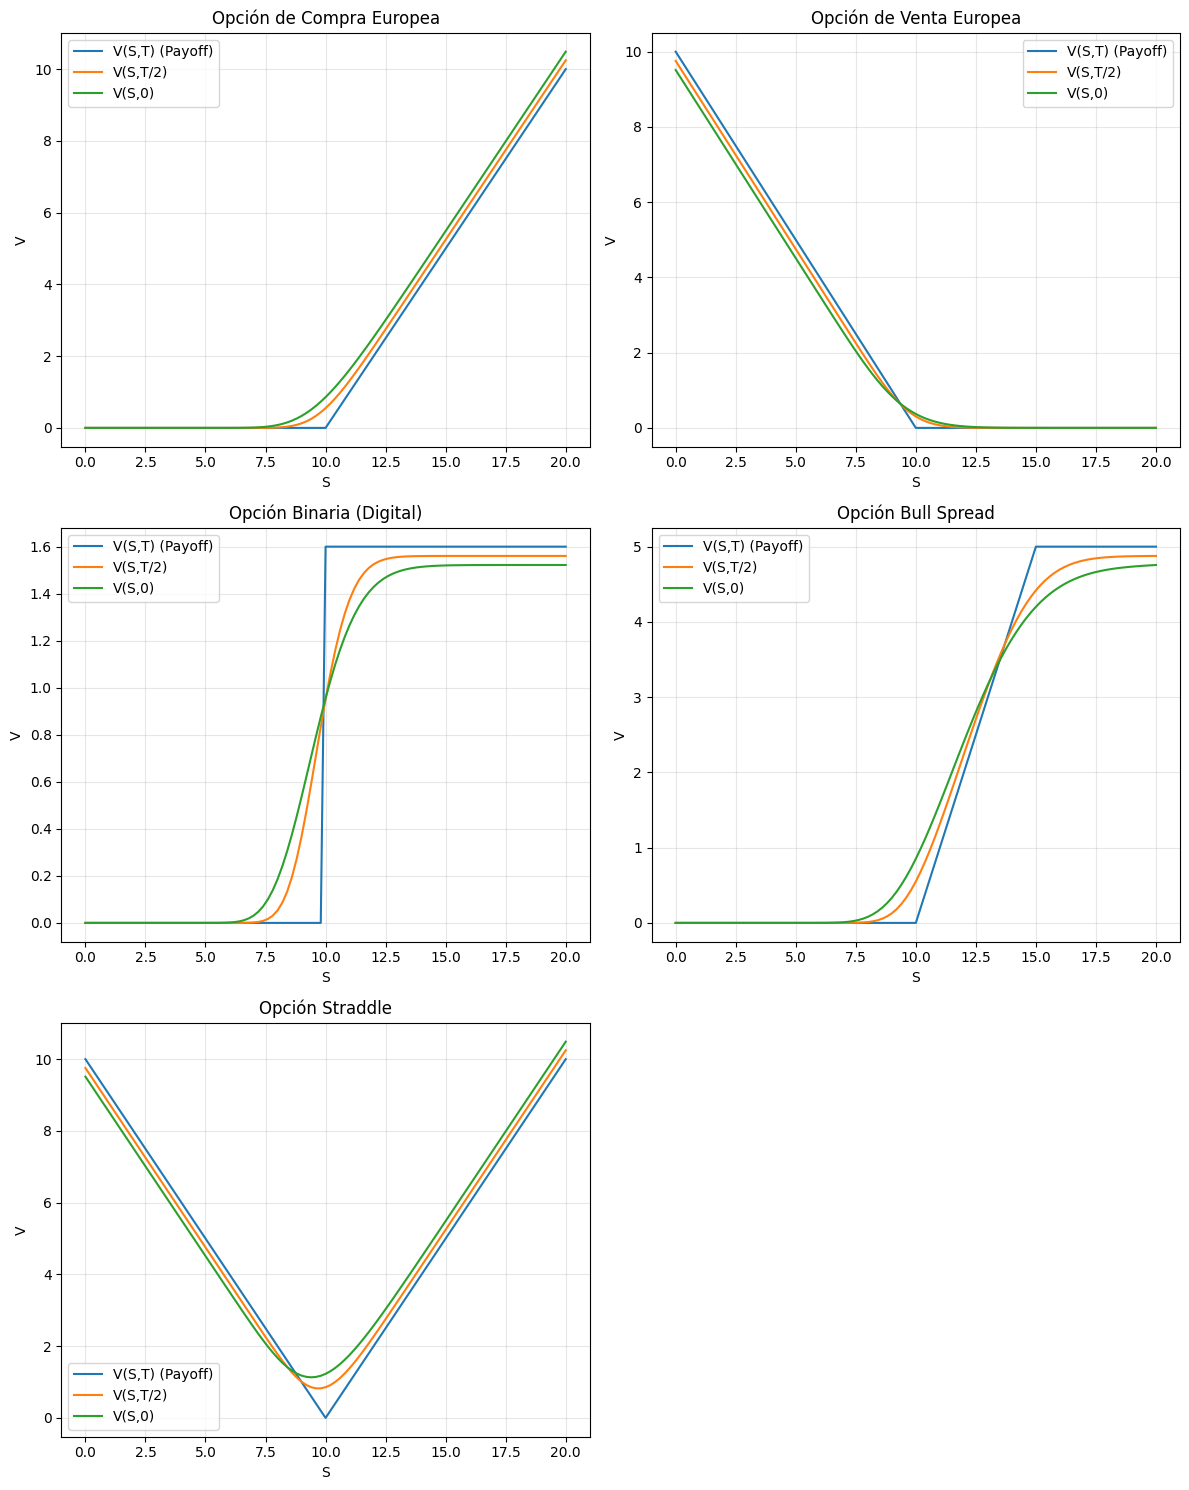

In [12]:
# Método de Crank-Nicholson para la ecuación de Black-Scholes
# Resolución iterativa para múltiples opciones

# Definición de los parámetros base del problema
r = 0.05
sigma = 0.15
T = 1.0
E = 10.0
E1 = 10.0
E2 = 15.0
rho = 0.6
Smax = 20.0
Smin = 0.0

Nt = 100
Ns = 100

dt = T / Nt
ds = (Smax - Smin) / Ns
tau = np.linspace(0, T, Nt + 1)
s = np.linspace(Smin, Smax, Ns + 1)

# Números de Courant
lambda1 = dt / ds**2
lambda2 = dt / ds

# Construcción de las Matrices A y B (Comunes para todas las opciones)
s_m = s[1:-1]

# Coeficientes del método Crank-Nicholson
a = -0.25 * sigma**2 * s_m**2 * lambda1 + 0.25 * r * s_m * lambda2
b = 0.5 * r * dt + 0.5 * sigma**2 * s_m**2 * lambda1
c = -0.25 * sigma**2 * s_m**2 * lambda1 - 0.25 * r * s_m * lambda2

# Matriz A (Instante n+1)
A = np.diag(1 + b) + np.diag(a[1:], k=-1) + np.diag(c[:-1], k=1)

# Matriz B (Instante n)
B = np.diag(1 - b) + np.diag(-a[1:], k=-1) + np.diag(-c[:-1], k=1)

# Definición del Solver Numérico
def black_scholes_crank_nicholson(payoff, bc_0, bc_smax):
    V = np.zeros((Ns + 1, Nt + 1))
    V[:, 0] = payoff
    
    # Iteración temporal 
    for n in range(Nt):
        # Actualizamos contornos para instantes n y n+1
        V[0, n] = bc_0(tau[n])
        V[-1, n] = bc_smax(tau[n])
        V[0, n+1] = bc_0(tau[n+1])
        V[-1, n+1] = bc_smax(tau[n+1])
        
        # Términos independientes (Condiciones de contorno)
        Gamma = np.zeros(Ns - 1)
        Gamma[0] = -a[0] * V[0, n]
        Gamma[-1] = -c[-1] * V[-1, n]
        
        Lambda = np.zeros(Ns - 1)
        Lambda[0] = -a[0] * V[0, n+1]
        Lambda[-1] = -c[-1] * V[-1, n+1]
        
        # Lado derecho de la ecuación matricial
        RHS = B.dot(V[1:-1, n]) + Gamma + Lambda
        
        # Resolución del sistema lineal
        V[1:-1, n+1] = solve(A, RHS)
        
    return V

# Funciones auxiliares para visualización
def plot_option(V, title):
    plt.plot(s, V[:, 0], label='V(S,T) (Payoff)')
    plt.plot(s, V[:, int((Nt+1)/2)], label='V(S,T/2)')
    plt.plot(s, V[:, Nt], label='V(S,0)')
    plt.xlabel('S')
    plt.ylabel('V')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)

# Ejecución para cada opción y generación de gráficos
plt.figure(figsize=(12, 15))

# Opción de Compra Europea
payoff_call = np.maximum(s - E, 0)
bc_0_call = lambda t: 0
bc_smax_call = lambda t: Smax - E * np.exp(-r * t)
V_call = black_scholes_crank_nicholson(payoff_call, bc_0_call, bc_smax_call)

plt.subplot(3, 2, 1)
plot_option(V_call, 'Opción de Compra Europea')

# Opción de Venta Europea
payoff_put = np.maximum(E - s, 0)
bc_0_put = lambda t: E * np.exp(-r * t)
bc_smax_put = lambda t: 0
V_put = black_scholes_crank_nicholson(payoff_put, bc_0_put, bc_smax_put)

plt.subplot(3, 2, 2)
plot_option(V_put, 'Opción de Venta Europea')

# Opción Binaria / Digital
payoff_digital = (1 + rho) * np.heaviside(s - E, 1)
bc_0_digital = lambda t: 0
bc_smax_digital = lambda t: (1 + rho) * np.exp(-r * t)
V_digital = black_scholes_crank_nicholson(payoff_digital, bc_0_digital, bc_smax_digital)

plt.subplot(3, 2, 3)
plot_option(V_digital, 'Opción Binaria (Digital)')

# Opción Bull Spread
payoff_bull = np.maximum(s - E1, 0) - np.maximum(s - E2, 0)
bc_0_bull = lambda t: 0
bc_smax_bull = lambda t: (E2 - E1) * np.exp(-r * t)
V_bull = black_scholes_crank_nicholson(payoff_bull, bc_0_bull, bc_smax_bull)

plt.subplot(3, 2, 4)
plot_option(V_bull, 'Opción Bull Spread')

# Opción Straddle
payoff_straddle = np.abs(s - E)
bc_0_straddle = lambda t: E * np.exp(-r * t)
bc_smax_straddle = lambda t: Smax - E * np.exp(-r * t)
V_straddle = black_scholes_crank_nicholson(payoff_straddle, bc_0_straddle, bc_smax_straddle)

plt.subplot(3, 2, 5)
plot_option(V_straddle, 'Opción Straddle')

plt.tight_layout()
plt.show()

# Problema 2: Análisis de la sensibilidad (Griegas)

En este problema vamos a analizar la variación del valor de la opción con respecto a dos parámetros de la ecuación: la volatilidad $\sigma$ y el tipo de interés $r$. Estas variaciones son lo que se conocen como las griegas “Vega” ($\nu$) y “Rho” ($\rho$). Para ello considera una opción de compra europea $V(S,T) = \max\{S - E, 0\}$. Usa los valores de referencia para los parámetros del script 18: $E = 10$, $S_{\max} = 20$, $T = 1$.

---

## Apartado a) Variación respecto a la volatilidad $\sigma$

Para este apartado, debemos fijar el tipo de interés en $r = 0.2$ y evaluar cómo cambia el valor actual de la opción (en $t=0$, que corresponde a $\tau = T$) cuando el precio del subyacente es exactamente igual al precio de ejercicio ($S = E$). Resolveremos la ecuación utilizando el método implícito BTCS (Backward Time Centered Space).

El método BTCS es incondicionalmente estable y se formula matricialmente evaluando las derivadas espaciales en el instante futuro $n+1$. Esto nos lleva a resolver en cada paso de tiempo un sistema tridiagonal de la forma:

$$A \vec{V}_{n+1} = \vec{V}_n + \vec{b}_{n+1}$$

Donde los coeficientes de la matriz $A$ están formados por:
* Subdiagonal: $-\frac{1}{2}\sigma^2 S_m^2 \lambda_1 + \frac{r}{2}S_m \lambda_2$
* Diagonal principal: $1 + r\Delta t + \sigma^2 S_m^2 \lambda_1$
* Superdiagonal: $-\frac{1}{2}\sigma^2 S_m^2 \lambda_1 - \frac{r}{2}S_m \lambda_2$

Para obtener la gráfica $V(E,0)$ vs $\sigma$, implementaremos una función que resuelva el modelo BTCS completo para un $\sigma$ dado. Luego, iteraremos sobre un rango de volatilidades, extrayendo el valor de la opción en el nodo espacial correspondiente a $S=E$, y almacenaremos estos resultados para su visualización.

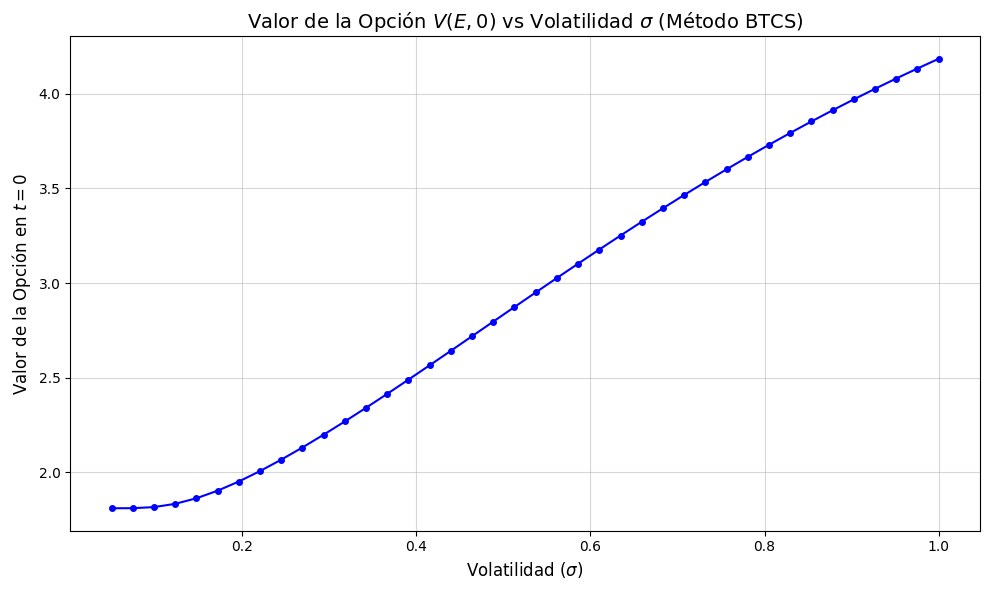

In [13]:
# Resolución del Problema 2 - Apartado a
# Método BTCS iterativo para evaluar V(E,0) vs volatilidad (sigma)

def btcs_option_value(sigma, r, E, Smax, T, Ns, Nt):
    """
    Resuelve la ecuación de Black-Scholes por BTCS para una Call Europea
    y devuelve el valor de la opción en S = E y tau = T (t = 0).
    """
    dt = T / Nt
    ds = Smax / Ns
    s = np.linspace(0, Smax, Ns + 1)
    tau = np.linspace(0, T, Nt + 1)
    
    # Parámetros de Courant
    lambda1 = dt / ds**2
    lambda2 = dt / ds
    
    s_m = s[1:-1] # Nodos interiores
    
    # Coeficientes de la matriz tridiagonal A
    lower = -0.5 * sigma**2 * s_m**2 * lambda1 + 0.5 * r * s_m * lambda2
    main = 1 + r * dt + sigma**2 * s_m**2 * lambda1
    upper = -0.5 * sigma**2 * s_m**2 * lambda1 - 0.5 * r * s_m * lambda2
    
    # Construcción de la Matriz A
    A = np.diag(main) + np.diag(lower[1:], k=-1) + np.diag(upper[:-1], k=1)
    
    # Condición Inicial (Payoff de Call Europea en tau = 0)
    V = np.maximum(s - E, 0)
    
    # Iteración temporal explícita (resolviendo implícitamente el espacio)
    for n in range(Nt):
        # Condiciones de contorno en el instante tau_n+1
        V_0 = 0
        V_Smax = Smax - E * np.exp(-r * tau[n+1])
        
        # Lado derecho de la ecuación
        RHS = V[1:-1].copy()
        
        # Incorporación de términos independientes (contornos)
        RHS[0] -= lower[0] * V_0
        RHS[-1] -= upper[-1] * V_Smax
        
        # Resolver el sistema
        V[1:-1] = solve(A, RHS)
        V[0] = V_0
        V[-1] = V_Smax
        
    # Identificar el índice correspondiente a S = E
    # (Usamos isclose para evitar problemas de precisión en coma flotante)
    idx_E = np.where(np.isclose(s, E))[0][0]
    
    return V[idx_E]

# Configuración de parámetros
r_val = 0.2
E_val = 10.0
Smax_val = 20.0
T_val = 1.0
Ns_val = 100
Nt_val = 100

# Rango de volatilidades a explorar (ej. de 5% a 100%)
sigma_array = np.linspace(0.05, 1.0, 40)
V_E_array = np.zeros_like(sigma_array)

# Cálculo de V(E,0) para cada volatilidad
for i, sig in enumerate(sigma_array):
    V_E_array[i] = btcs_option_value(sig, r_val, E_val, Smax_val, T_val, Ns_val, Nt_val)

# Generación de la gráfica
plt.figure(figsize=(10, 6))
plt.plot(sigma_array, V_E_array, marker='o', linestyle='-', color='b', markersize=4)
plt.title(r'Valor de la Opción $V(E,0)$ vs Volatilidad $\sigma$ (Método BTCS)', fontsize=14)
plt.xlabel(r'Volatilidad ($\sigma$)', fontsize=12)
plt.ylabel(r'Valor de la Opción en $t=0$', fontsize=12)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## Apartado b) Variación respecto al tipo de interés $r$

En este apartado, procedemos de manera análoga al caso anterior, pero intercambiando los roles de los parámetros. Ahora fijaremos la volatilidad en $\sigma = 0.25$ y evaluaremos cómo cambia el valor actual de la opción ($t=0$, es decir, $\tau = T$) cuando el precio del subyacente es igual al precio de ejercicio ($S = E$), en función del tipo de interés $r$.

Seguiremos utilizando el método implícito BTCS. La estructura del sistema tridiagonal es idéntica, pero en esta ocasión el bucle de exploración iterará sobre un vector de posibles valores para la tasa de interés libre de riesgo $r$, manteniendo la volatilidad constante. 

El resultado será la representación gráfica de la sensibilidad del precio de la opción frente a los cambios en el tipo de interés, lo cual es la base para entender la griega "Rho" ($\rho$).

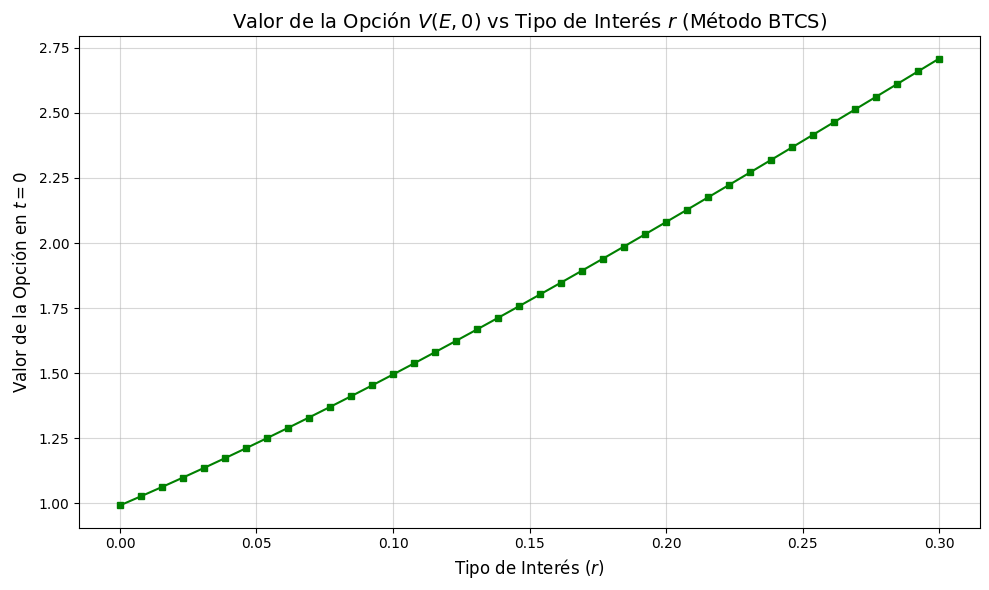

In [14]:
# Resolución del Problema 2 - Apartado b
# Evaluación de V(E,0) vs tipo de interés (r) usando el método BTCS

# Parámetros fijos para este apartado
sigma_val = 0.25
E_val = 10.0
Smax_val = 20.0
T_val = 1.0
Ns_val = 100
Nt_val = 100

# Rango de tipos de interés a explorar (ej. de 0% a 30%)
r_array = np.linspace(0.0, 0.30, 40)
V_E_r_array = np.zeros_like(r_array)

# Redefinimos brevemente la función de resolución BTCS para asegurar su ejecución independiente
def solve_btcs_for_r(sigma, r, E, Smax, T, Ns, Nt):
    dt = T / Nt
    ds = Smax / Ns
    s = np.linspace(0, Smax, Ns + 1)
    tau = np.linspace(0, T, Nt + 1)
    
    # Parámetros de Courant
    lambda1 = dt / ds**2
    lambda2 = dt / ds
    
    s_m = s[1:-1] # Nodos interiores
    
    # Coeficientes de la matriz tridiagonal A
    lower = -0.5 * sigma**2 * s_m**2 * lambda1 + 0.5 * r * s_m * lambda2
    main = 1 + r * dt + sigma**2 * s_m**2 * lambda1
    upper = -0.5 * sigma**2 * s_m**2 * lambda1 - 0.5 * r * s_m * lambda2
    
    A = np.diag(main) + np.diag(lower[1:], k=-1) + np.diag(upper[:-1], k=1)
    
    # Condición Inicial (Payoff de Call Europea en tau = 0)
    V = np.maximum(s - E, 0)
    
    # Iteración temporal implícita
    for n in range(Nt):
        V_0 = 0
        V_Smax = Smax - E * np.exp(-r * tau[n+1])
        
        RHS = V[1:-1].copy()
        RHS[0] -= lower[0] * V_0
        RHS[-1] -= upper[-1] * V_Smax
        
        V[1:-1] = solve(A, RHS)
        V[0] = V_0
        V[-1] = V_Smax
        
    idx_E = np.where(np.isclose(s, E))[0][0]
    return V[idx_E]

# Cálculo de V(E,0) para cada tasa de interés
for i, r_rate in enumerate(r_array):
    V_E_r_array[i] = solve_btcs_for_r(sigma_val, r_rate, E_val, Smax_val, T_val, Ns_val, Nt_val)

# Generación de la gráfica
plt.figure(figsize=(10, 6))
plt.plot(r_array, V_E_r_array, marker='s', linestyle='-', color='g', markersize=4)
plt.title(r'Valor de la Opción $V(E,0)$ vs Tipo de Interés $r$ (Método BTCS)', fontsize=14)
plt.xlabel(r'Tipo de Interés ($r$)', fontsize=12)
plt.ylabel(r'Valor de la Opción en $t=0$', fontsize=12)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

## Apartado c) Cálculo de las Griegas Vega y Rho mediante Diferencias Finitas

En este último apartado vamos a calcular y visualizar las griegas Vega ($\nu$) y Rho ($\rho$) en función del precio del subyacente $S$. Para ello, aproximaremos las derivadas parciales utilizando el método de diferencias finitas centradas, que es numéricamente más estable y preciso que usar diferencias hacia adelante o hacia atrás.

Dado un pequeño incremento $\Delta$, las aproximaciones quedan definidas como:

$$\nu = \frac{\partial V}{\partial \sigma} \approx \frac{V(S, \sigma + \Delta \sigma) - V(S, \sigma - \Delta \sigma)}{2\Delta \sigma}$$

$$\rho = \frac{\partial V}{\partial r} \approx \frac{V(S, r + \Delta r) - V(S, r - \Delta r)}{2\Delta r}$$

Para evaluar estas derivadas, usaremos los valores de referencia propuestos combinando la información de los apartados anteriores: un tipo de interés $r = 0.2$ y una volatilidad $\sigma = 0.25$. Resolveremos el modelo BTCS para los estados perturbados y aplicaremos las fórmulas sobre el vector de precios resultante en el instante $t=0$ ($\tau=T$).

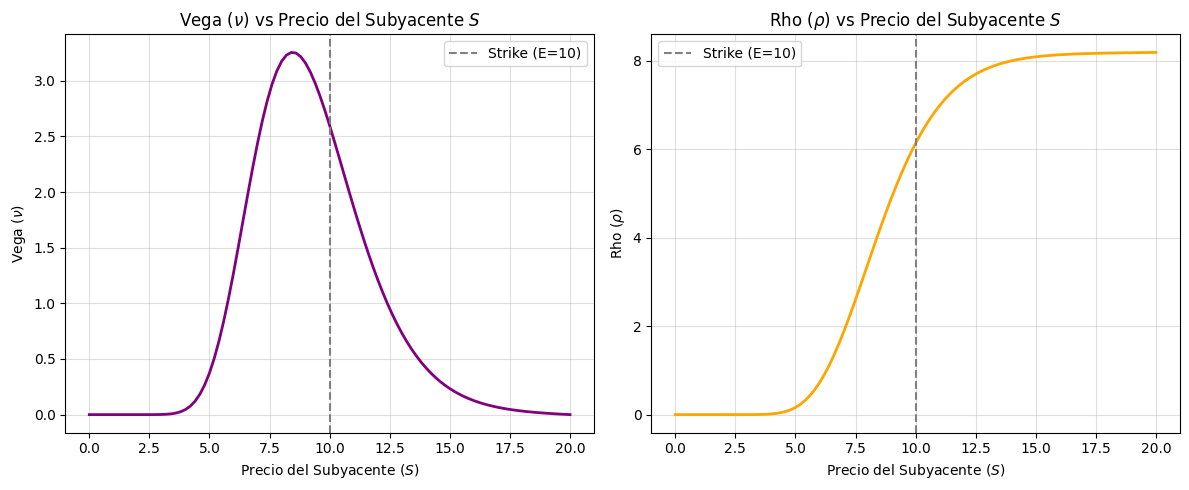

In [15]:
# Resolución del Problema 2 - Apartado c
# Cálculo de Vega y Rho mediante diferencias finitas

# Parámetros base de referencia
r_base = 0.2
sigma_base = 0.25
E = 10.0
Smax = 20.0
T = 1.0
Ns = 100
Nt = 100

# Incrementos para las diferencias finitas
d_sigma = 0.01
d_r = 0.01

def btcs_full_curve(sigma, r, E, Smax, T, Ns, Nt):
    """
    Resuelve la PDE por BTCS y devuelve la curva completa de precios
    de la opción para todos los valores de S en el instante actual t=0 (tau=T).
    """
    dt = T / Nt
    ds = Smax / Ns
    s = np.linspace(0, Smax, Ns + 1)
    tau = np.linspace(0, T, Nt + 1)
    
    lambda1 = dt / ds**2
    lambda2 = dt / ds
    
    s_m = s[1:-1]
    
    lower = -0.5 * sigma**2 * s_m**2 * lambda1 + 0.5 * r * s_m * lambda2
    main = 1 + r * dt + sigma**2 * s_m**2 * lambda1
    upper = -0.5 * sigma**2 * s_m**2 * lambda1 - 0.5 * r * s_m * lambda2
    
    A = np.diag(main) + np.diag(lower[1:], k=-1) + np.diag(upper[:-1], k=1)
    
    V = np.maximum(s - E, 0)
    
    for n in range(Nt):
        V_0 = 0
        V_Smax = Smax - E * np.exp(-r * tau[n+1])
        
        RHS = V[1:-1].copy()
        RHS[0] -= lower[0] * V_0
        RHS[-1] -= upper[-1] * V_Smax
        
        V[1:-1] = solve(A, RHS)
        V[0] = V_0
        V[-1] = V_Smax
        
    return V

# Vector de precios del subyacente para el eje X
S_array = np.linspace(0, Smax, Ns + 1)

# Cálculo numérico de Vega usando diferencias centradas
V_sigma_plus = btcs_full_curve(sigma_base + d_sigma, r_base, E, Smax, T, Ns, Nt)
V_sigma_minus = btcs_full_curve(sigma_base - d_sigma, r_base, E, Smax, T, Ns, Nt)
Vega = (V_sigma_plus - V_sigma_minus) / (2 * d_sigma)

# Cálculo numérico de Rho usando diferencias centradas
V_r_plus = btcs_full_curve(sigma_base, r_base + d_r, E, Smax, T, Ns, Nt)
V_r_minus = btcs_full_curve(sigma_base, r_base - d_r, E, Smax, T, Ns, Nt)
Rho = (V_r_plus - V_r_minus) / (2 * d_r)

# Visualización de los resultados
plt.figure(figsize=(12, 5))

# Gráfica de Vega
plt.subplot(1, 2, 1)
plt.plot(S_array, Vega, color='purple', linewidth=2)
plt.axvline(x=E, color='grey', linestyle='--', label='Strike (E=10)')
plt.title(r'Vega ($\nu$) vs Precio del Subyacente $S$')
plt.xlabel('Precio del Subyacente ($S$)')
plt.ylabel(r'Vega ($\nu$)')
plt.legend()
plt.grid(True, alpha=0.4)

# Gráfica de Rho
plt.subplot(1, 2, 2)
plt.plot(S_array, Rho, color='orange', linewidth=2)
plt.axvline(x=E, color='grey', linestyle='--', label='Strike (E=10)')
plt.title(r'Rho ($\rho$) vs Precio del Subyacente $S$')
plt.xlabel('Precio del Subyacente ($S$)')
plt.ylabel(r'Rho ($\rho$)')
plt.legend()
plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## Conclusiones sobre la valoración de la opción:

* **Efecto de la Volatilidad (Vega $\nu$):**
  * Observando la gráfica del valor de la opción frente a $\sigma$, confirmamos que el valor crece de forma monótona a medida que aumenta la volatilidad. Al estar las pérdidas de una opción Call limitadas a cero (nunca será negativa), una mayor dispersión en los precios del subyacente solo incrementa el potencial de ganancias, haciendo el contrato más valioso.
  * Analizando la gráfica de Vega frente al precio del subyacente ($S$), vemos una clara curva en forma de campana. Vega es siempre positiva, pero su pico máximo no se encuentra exactamente en $S=E$, sino desplazado hacia la izquierda (alrededor de $S \approx 7.9$). Esto ocurre porque Vega se maximiza cuando el parámetro $d_1$ de Black-Scholes es igual a cero. Debido al alto tipo de interés libre de riesgo utilizado en el ejercicio ($r=0.2$), el valor "At-The-Money Forward" (que tiene en cuenta el coste de financiación) se alcanza a un precio *spot* del subyacente inferior al precio de ejercicio. A medida que la opción se aleja hacia zonas muy "In-The-Money" o muy "Out-of-The-Money", Vega tiende a cero porque la incertidumbre sobre el ejercicio de la opción desaparece.

* **Efecto del Tipo de Interés (Rho $\rho$):**
  * La gráfica del valor de la opción frente a $r$ muestra una relación creciente casi lineal. Un aumento en los tipos de interés incrementa el valor de la opción de compra europea.
  * Al revisar la curva de Rho frente a $S$, notamos un comportamiento sigmoidal (en forma de "S"). Para valores bajos de $S$ (opciones profundamente OTM), Rho es cercana a cero porque la opción apenas tiene probabilidad de ser ejercida. Sin embargo, a medida que la opción se acerca a "In-The-Money" ($S > E$), Rho crece rápidamente y tiende a estabilizarse de forma asintótica en un valor máximo. Esto tiene una justificación financiera clara: si es casi seguro que ejerceremos la opción, tendremos que pagar $E$ en el futuro. Si los tipos de interés suben, el valor presente (descontado) de ese desembolso de $E$ es menor. Como nos cuesta "menos" dinero hoy garantizar esa compra futura, el derecho a comprar se vuelve más valioso.

# Problema 3: Estimación de las Griegas mediante Diferencias Finitas

En este problema vamos a estimar las griegas para una opción de compra europea con los parámetros dados en el script base. Las griegas que hay que estimar son:

* **Delta:** $\Delta = \frac{\partial V}{\partial S}$
* **Gamma:** $\Gamma = \frac{\partial^2 V}{\partial S^2}$
* **Theta:** $\Theta = -\frac{\partial V}{\partial T}$
* **Vega:** $\nu = \frac{\partial V}{\partial \sigma}$
* **Rho:** $\rho = \frac{\partial V}{\partial r}$

Para cada una de estas griegas, representaremos su valor en función del subyacente ($S$) para diferentes tiempos hasta el vencimiento ($\tau$). Aproximaremos las derivadas parciales usando diferencias centradas.

---

## Metodología de Cálculo Numérico

Para estimar estas sensibilidades, dividiremos el cálculo en dos grupos según la naturaleza de la derivada:

**1. Derivadas Espaciales (Delta y Gamma):**
Dado que ya calculamos la matriz completa de precios $V(S, \tau)$ para todo el dominio espacial, no necesitamos recalcular el modelo. Podemos aplicar diferencias finitas centradas directamente sobre la malla espacial obtenida:
* $\Delta_m \approx \frac{V_{m+1, n} - V_{m-1, n}}{2\Delta S}$
* $\Gamma_m \approx \frac{V_{m+1, n} - 2V_{m, n} + V_{m-1, n}}{\Delta S^2}$

**2. Derivadas Paramétricas (Theta, Vega y Rho):**
Al ser derivadas con respecto a parámetros fijos del modelo ($T$, $\sigma$, $r$), necesitamos evaluar la ecuación de Black-Scholes para un escenario ligeramente superior (p. ej., $\sigma + \Delta \sigma$) y otro ligeramente inferior (p. ej., $\sigma - \Delta \sigma$).
Tal y como sugiere el enunciado para Vega, si tomamos $\sigma = 0.25$, evaluaremos en $\sigma = 0.30$ y $\sigma = 0.20$, de manera que la diferencia centrada queda:
$$\nu \approx \frac{V_{\sigma=0.30} - V_{\sigma=0.20}}{0.10}$$

Aplicaremos esta misma lógica para Rho (perturbando $r$) y para Theta (perturbando la madurez $T$). A continuación, generaremos un panel con las 5 gráficas mostrando la evolución temporal desde el vencimiento ($\tau=0$) hasta el momento actual ($\tau=T$).

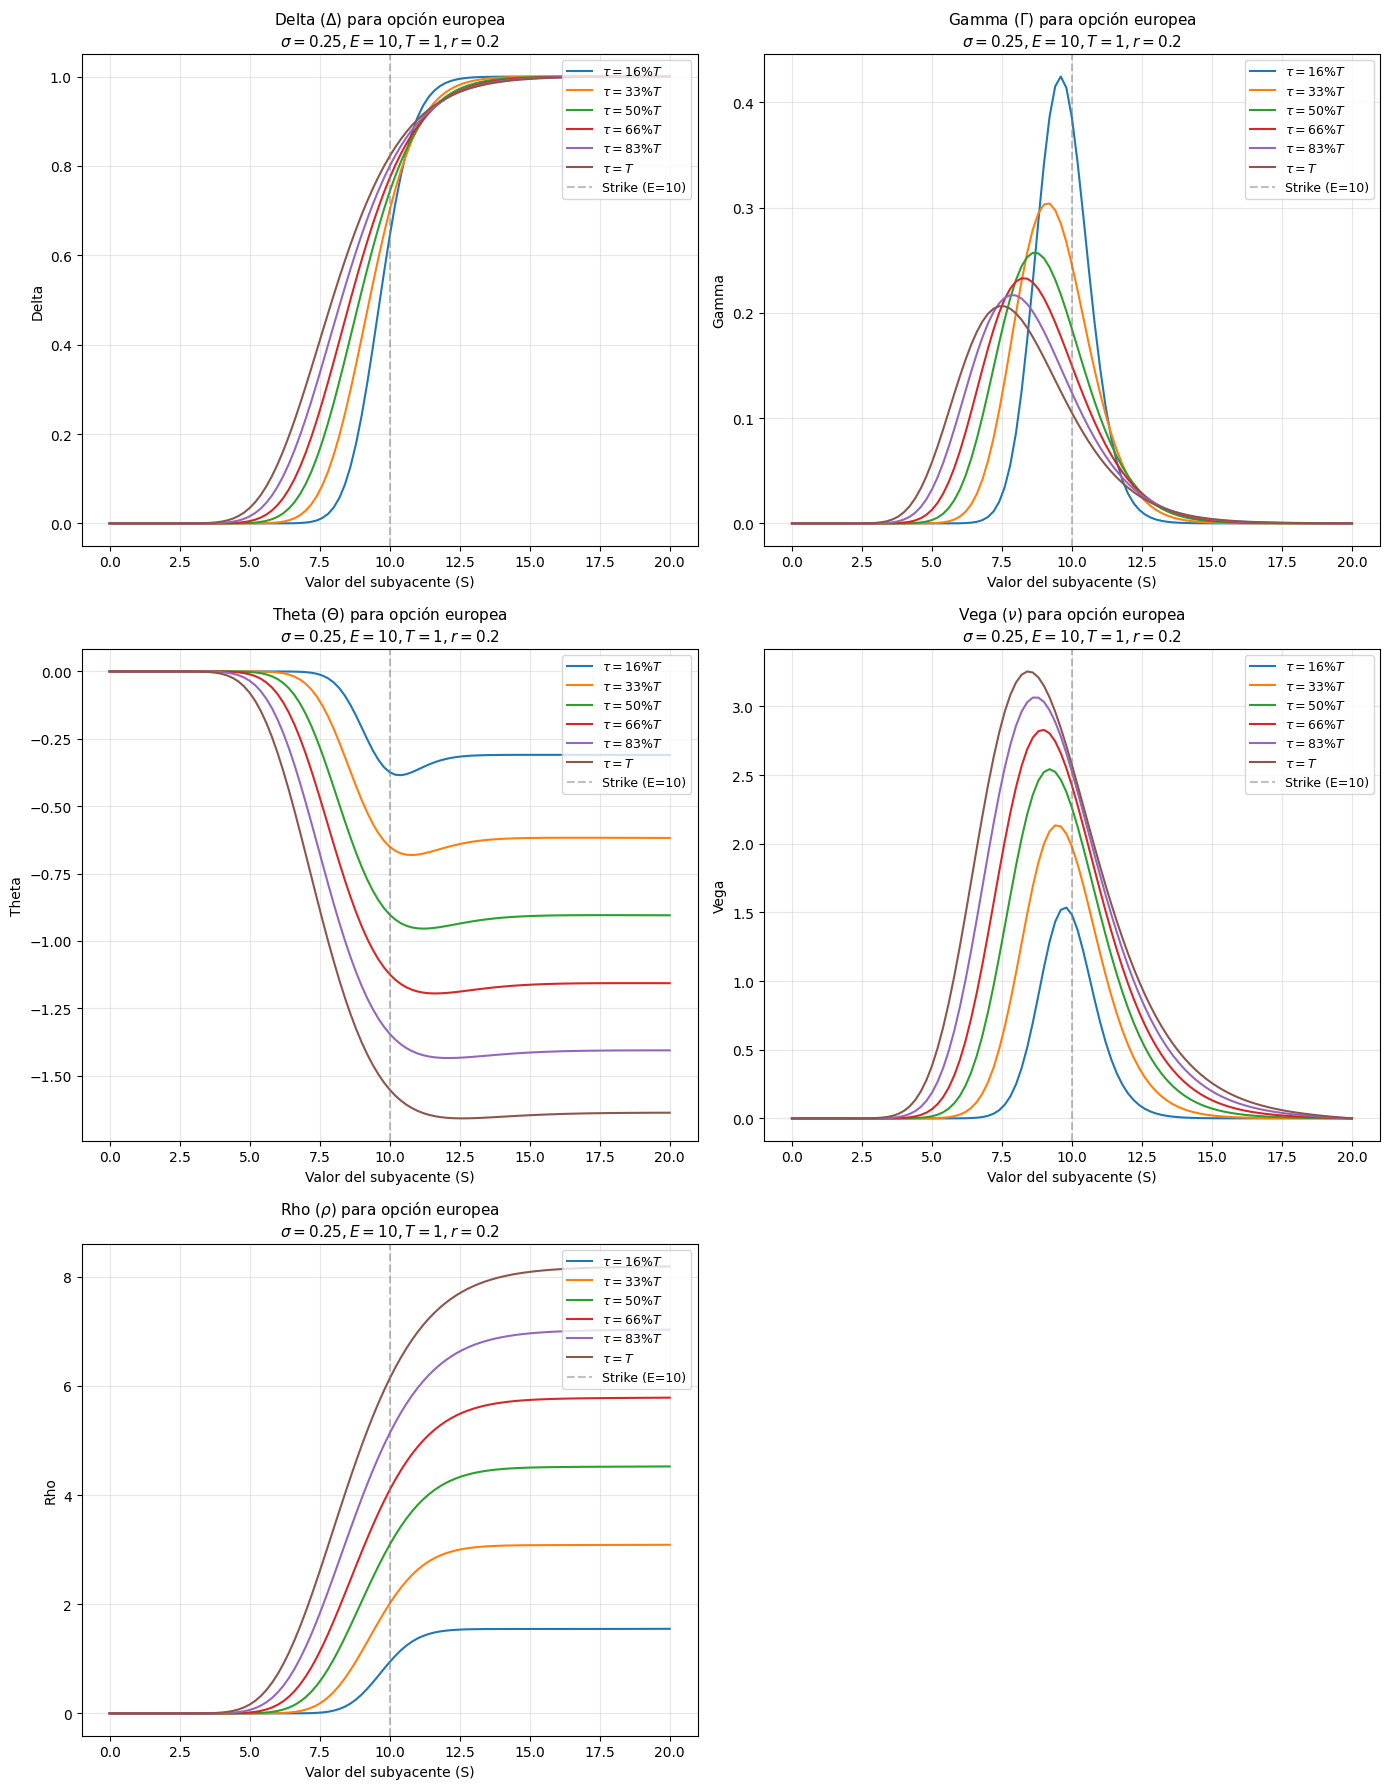

In [16]:
# Resolución del Problema 3
# Estimación de Griegas usando diferencias finitas centradas

# Parámetros base
r = 0.2
sigma = 0.25
T = 1.0
E = 10.0
Smax = 20.0
Ns = 100
Nt = 100

ds = Smax / Ns
dt = T / Nt
s = np.linspace(0, Smax, Ns + 1)

# Función encapsulada para obtener la matriz V completa rápidamente
def solve_btcs_full(sigma_val, r_val, T_val):
    dt_val = T_val / Nt
    tau_val = np.linspace(0, T_val, Nt + 1)
    
    lam1 = dt_val / ds**2
    lam2 = dt_val / ds
    s_m = s[1:-1]
    
    lower = -0.5 * sigma_val**2 * s_m**2 * lam1 + 0.5 * r_val * s_m * lam2
    main = 1 + r_val * dt_val + sigma_val**2 * s_m**2 * lam1
    upper = -0.5 * sigma_val**2 * s_m**2 * lam1 - 0.5 * r_val * s_m * lam2
    
    A = np.diag(main) + np.diag(lower[1:], k=-1) + np.diag(upper[:-1], k=1)
    
    V = np.zeros((Ns + 1, Nt + 1))
    V[:, 0] = np.maximum(s - E, 0)
    
    for n in range(Nt):
        V_0 = 0
        V_Smax = Smax - E * np.exp(-r_val * tau_val[n+1])
        
        RHS = V[1:-1, n].copy()
        RHS[0] -= lower[0] * V_0
        RHS[-1] -= upper[-1] * V_Smax
        
        V[1:-1, n+1] = solve(A, RHS)
        V[0, n+1] = V_0
        V[-1, n+1] = V_Smax
        
    return V

# 1. Matriz Base y Griegas Espaciales (Delta y Gamma)
V_base = solve_btcs_full(sigma, r, T)

Delta = np.zeros_like(V_base)
Gamma = np.zeros_like(V_base)

# Diferencias centradas para nodos interiores
Delta[1:-1, :] = (V_base[2:, :] - V_base[:-2, :]) / (2 * ds)
Gamma[1:-1, :] = (V_base[2:, :] - 2 * V_base[1:-1, :] + V_base[:-2, :]) / (ds**2)

# Aproximaciones en los bordes para mantener consistencia gráfica
Delta[0, :] = (V_base[1, :] - V_base[0, :]) / ds
Delta[-1, :] = (V_base[-1, :] - V_base[-2, :]) / ds
Gamma[0, :] = Gamma[1, :]
Gamma[-1, :] = Gamma[-2, :]

# 2. Griegas Paramétricas (Vega, Rho, Theta)
# Vega (perturbación de +- 0.05 en sigma, denominador = 0.10)
V_sigma_plus = solve_btcs_full(sigma + 0.05, r, T)
V_sigma_minus = solve_btcs_full(sigma - 0.05, r, T)
Vega = (V_sigma_plus - V_sigma_minus) / 0.10

# Rho (perturbación de +- 0.01 en r, denominador = 0.02)
V_r_plus = solve_btcs_full(sigma, r + 0.01, T)
V_r_minus = solve_btcs_full(sigma, r - 0.01, T)
Rho = (V_r_plus - V_r_minus) / 0.02

# Theta (perturbación de +- 0.01 en T, denominador = 0.02)
V_T_plus = solve_btcs_full(sigma, r, T + 0.01)
V_T_minus = solve_btcs_full(sigma, r, T - 0.01)
Theta = -(V_T_plus - V_T_minus) / 0.02

# 3. Visualización de Resultados
# Índices temporales a graficar (porcentajes de T) - Corregido el % para LaTeX
tau_indices = [16, 33, 50, 66, 83, 100]
tau_labels = [r'16\% T', r'33\% T', r'50\% T', r'66\% T', r'83\% T', 'T']

fig, axs = plt.subplots(3, 2, figsize=(14, 18))
axs = axs.flatten()

greeks = [
    (Delta, r'Delta ($\Delta$)', axs[0]),
    (Gamma, r'Gamma ($\Gamma$)', axs[1]),
    (Theta, r'Theta ($\Theta$)', axs[2]),
    (Vega,  r'Vega ($\nu$)',     axs[3]),
    (Rho,   r'Rho ($\rho$)',     axs[4])
]

# Función para estilar cada subplot
def plot_greek(greek_matrix, title, ax):
    for idx, label in zip(tau_indices, tau_labels):
        ax.plot(s, greek_matrix[:, idx], label=rf'$\tau = {label}$')
        
    ax.axvline(x=E, color='grey', linestyle='--', alpha=0.5, label='Strike (E=10)')
    # Corregido el texto usando strings crudos (raw strings) para que lea bien el \sigma
    ax.set_title(title + r' para opción europea' + '\n' + r'$\sigma=0.25, E=10, T=1, r=0.2$', fontsize=11)
    ax.set_xlabel('Valor del subyacente (S)')
    ax.set_ylabel(title.split(' ')[0])
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

# Dibujar las 5 griegas
for matrix, title, ax in greeks:
    plot_greek(matrix, title, ax)

# Eliminar el 6º subplot vacío
fig.delaxes(axs[5])

plt.tight_layout()
plt.show()